### Notebook Overview

Building upon the linear baseline established in Stage 3, this notebook explores a variety of non-linear and ensemble machine learning algorithms to improve predictive performance on the Spotify Churn dataset. The feature set (231 features) is high-dimensional and has class imbalance, we will check if non-linear models fare better.

#### Objectives of this Phase

Implement and evaluate multiple classifiers, including KNN, Decision Trees, SVM (RBF), Random Forests, AdaBoost, and Gradient Boosting.

Utilize GridSearchCV to perform exhaustive hyperparameter tuning for each model, identifying the optimal configuration for depth, estimators, and regularization.

Apply Stratified K-Fold Cross-Validation during the tuning process to ensure model stability across the imbalanced 3:1 dataset.

Optimize specifically for the F1-Score to maximize the detection of churners while controlling for false positives.

Create a comparison table (Model, Train Time, Train Accuracy, Test Accuracy, F1-Score) to justify the final model choice.

### Load the Data

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load model-ready features and target
X = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/data/X_final_processed.parquet')
y = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/data/y_final_target.parquet').squeeze()

print(f"Features loaded: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features loaded: (8000, 231)
Target distribution:
is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64


### Stratified train-test split

In [40]:
# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 6400 rows
Testing set size: 1600 rows


### Comparison of Models

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_custom_cm(model, X_test, y_test, model_name="Model"):
    """
    Generates and plots a confusion matrix for a given model.
    
    Parameters:
    model: The classifier
    X_test: Test features.
    y_test: True labels for the test set.
    model_name: String name for the plot title.
    """
    # 1. Generate predictions
    y_pred = model.predict(X_test)
    
    # 2. Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Create the display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['Not Churned', 'Churned'])
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax)
    
    plt.title(f'Confusion Matrix: {model_name}')
    plt.grid(False)

    # Save logic
    file_path = os.path.join(viz_folder, f"{model_name.replace(' ', '_')}_CM.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {file_path}")

In [42]:
from sklearn.metrics import RocCurveDisplay
def plot_roc(model, X_test, y_test, model_name):
    """Generates, saves, and displays an ROC curve."""
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    plt.plot([0, 1], [0, 1], 'r--') # Random guess line
    
    title = f'{model_name} ROC Curve'
    plt.title(title)
    
    # Save logic
    file_path = os.path.join(viz_folder, f"{model_name.replace(' ', '_')}_ROC.png")
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {file_path}")

### Setup the Directory to save plots

In [43]:
import os

# Define the folder name
viz_folder = 'spotifyDataVisualizations'

# Create the folder if it doesn't already exist
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

### Setup Stratified K Fold

In [44]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### KNN

Best KNN Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best Cross-Val F1 Score: 0.2011


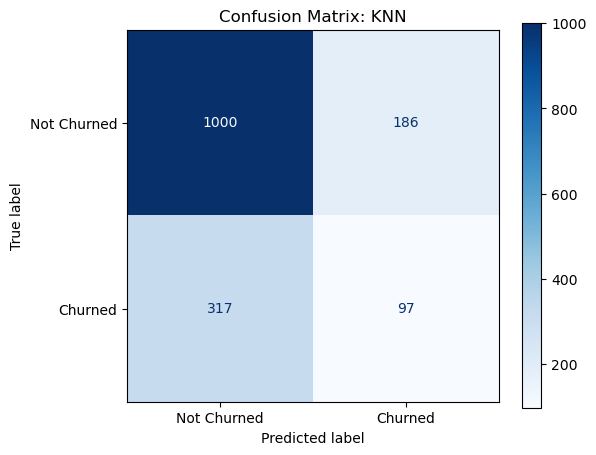

Saved: spotifyDataVisualizations/KNN_CM.png


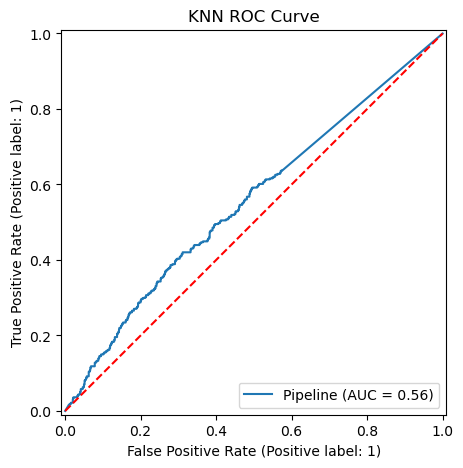

Saved: spotifyDataVisualizations/KNN_ROC.png


In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Define the Pipeline
knn_pipe = Pipeline([
    ('knn', KNeighborsClassifier())
])

# 2. Define the Parameter Grid
# We test different k values and weights (uniform vs distance-based)
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Initialize GridSearchCV
# Using the 'skf' StratifiedKFold
knn_grid = GridSearchCV(
    knn_pipe, 
    knn_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
knn_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {knn_grid.best_score_:.4f}")

# 6. Visualize Results using your custom functions
plot_custom_cm(knn_grid.best_estimator_, X_test, y_test, "KNN")
plot_roc(knn_grid.best_estimator_, X_test, y_test, "KNN")

### Decision Trees

Best Decision Tree Parameters: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_split': 10}
Best Cross-Val F1 Score: 0.3585


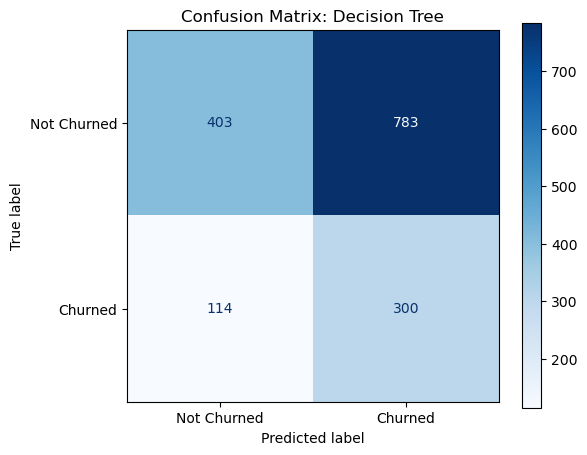

Saved: spotifyDataVisualizations/Decision_Tree_CM.png


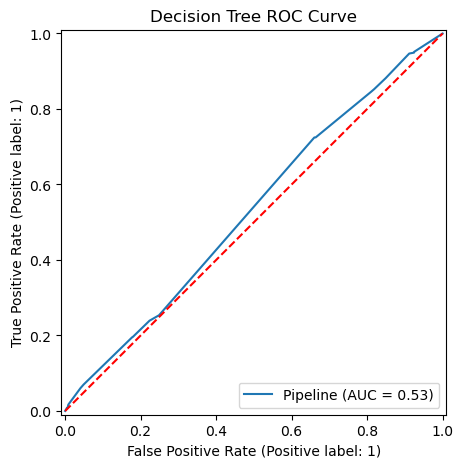

Saved: spotifyDataVisualizations/Decision_Tree_ROC.png


In [46]:
from sklearn.tree import DecisionTreeClassifier

# 1. Define the Pipeline
dt_pipe = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# We focus on depth and splitting criteria to prevent overfitting
dt_param_grid = {
    'dt__max_depth': [3, 5, 10, 20, None],
    'dt__min_samples_split': [2, 10, 20],
    'dt__class_weight': ['balanced', None], # 'balanced' helps with our churn class
    'dt__criterion': ['gini', 'entropy']
}

# 3. Initialize GridSearchCV
dt_grid = GridSearchCV(
    dt_pipe, 
    dt_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
dt_grid.fit(X_train, y_train)

# 5. Report Results
print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {dt_grid.best_score_:.4f}")

# 6. Visualize
plot_custom_cm(dt_grid.best_estimator_, X_test, y_test, "Decision Tree")
plot_roc(dt_grid.best_estimator_, X_test, y_test, "Decision Tree")

### SVM (RBF)

Best SVM Parameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'auto'}
Best Cross-Val F1 Score: 0.3345


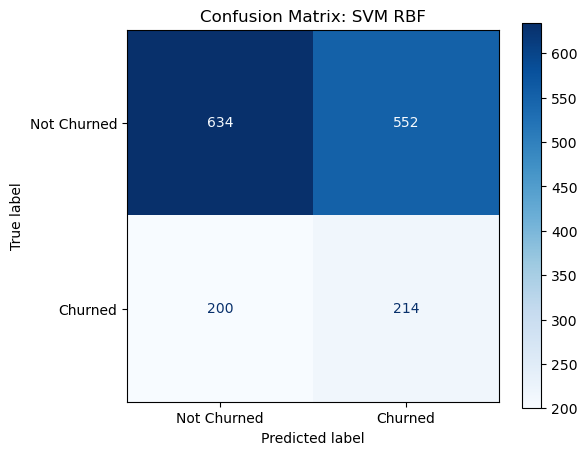

Saved: spotifyDataVisualizations/SVM_RBF_CM.png


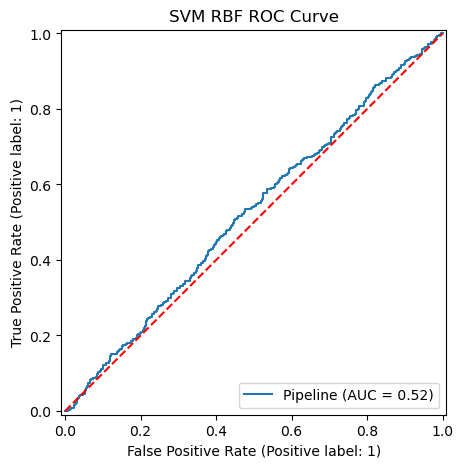

Saved: spotifyDataVisualizations/SVM_RBF_ROC.png


In [47]:
from sklearn.svm import SVC

# 1. Define Pipeline
svm_pipe = Pipeline([
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# 2. Define Parameter Grid
# C: Regularization (Higher = less regularization)
# gamma: How far the influence of a single training example reaches
svm_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': ['balanced'] 
}

# 3. GridSearchCV
svm_grid = GridSearchCV(
    svm_pipe, 
    svm_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit
svm_grid.fit(X_train, y_train)

# 5. Results
print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {svm_grid.best_score_:.4f}")

# 6. Visualize
plot_custom_cm(svm_grid.best_estimator_, X_test, y_test, "SVM RBF")
plot_roc(svm_grid.best_estimator_, X_test, y_test, "SVM RBF")

### Random Forest

Best RF Parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Best Cross-Val F1 Score: 0.2496


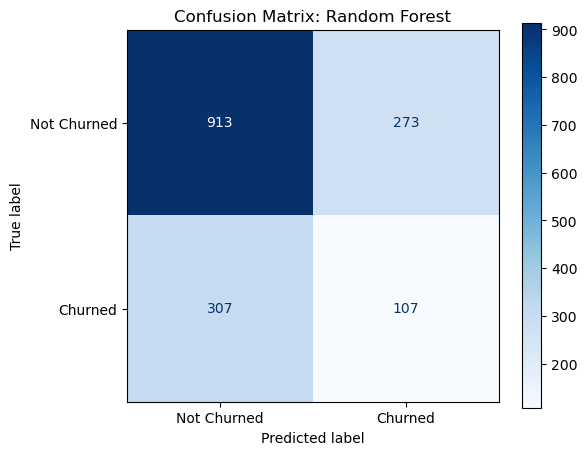

Saved: spotifyDataVisualizations/Random_Forest_CM.png


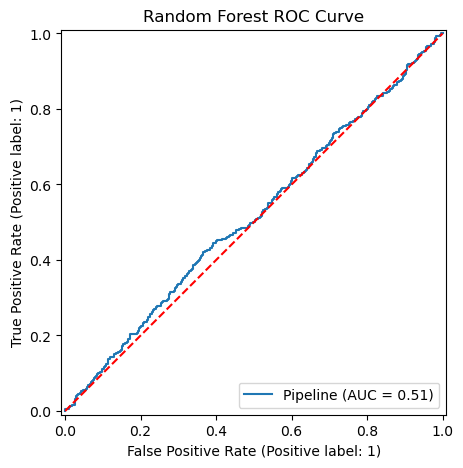

Saved: spotifyDataVisualizations/Random_Forest_ROC.png


In [48]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Pipeline
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# n_estimators: Number of trees in the forest
# max_depth: Limits tree growth to prevent overfitting
# class_weight: 'balanced' is crucial since we have fewer churners
rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__class_weight': ['balanced']
}

# 3. Initialize GridSearchCV with n_jobs=-1 for speed
rf_grid = GridSearchCV(
    rf_pipe, 
    rf_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
rf_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {rf_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(rf_grid.best_estimator_, X_test, y_test, "Random Forest")
plot_roc(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

### AdaBoost

Best AdaBoost Parameters: {'ada__learning_rate': 1.0, 'ada__n_estimators': 200}
Best Cross-Val F1 Score: 0.0036


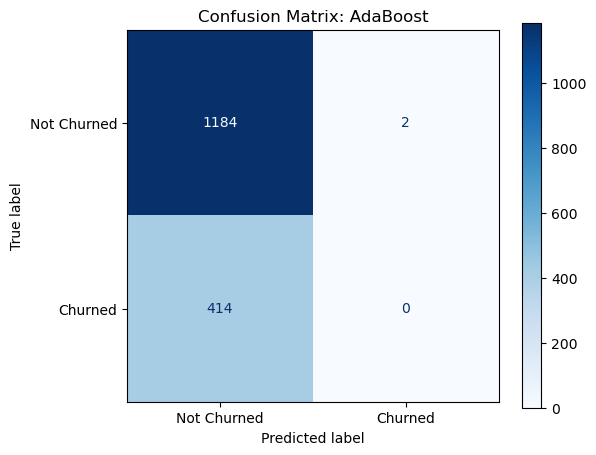

Saved: spotifyDataVisualizations/AdaBoost_CM.png


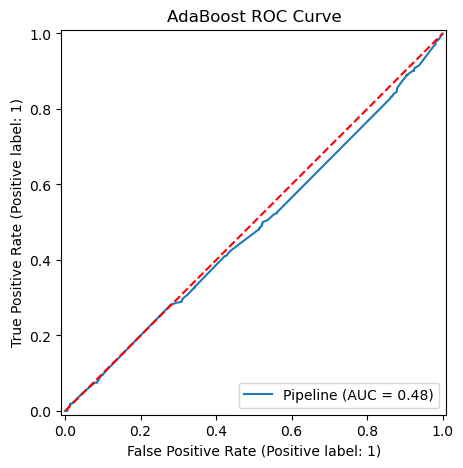

Saved: spotifyDataVisualizations/AdaBoost_ROC.png


In [49]:
from sklearn.ensemble import AdaBoostClassifier

# 1. Define the Pipeline
ada_pipe = Pipeline([
    ('ada', AdaBoostClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# n_estimators: Number of boosting stages
# learning_rate: Shrinks the contribution of each classifier (trade-off with n_estimators)
ada_param_grid = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.01, 0.1, 1.0],
}

# 3. Initialize GridSearchCV
ada_grid = GridSearchCV(
    ada_pipe, 
    ada_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
ada_grid.fit(X_train, y_train)

# 5. Report Best Parameters
print(f"Best AdaBoost Parameters: {ada_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {ada_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(ada_grid.best_estimator_, X_test, y_test, "AdaBoost")
plot_roc(ada_grid.best_estimator_, X_test, y_test, "AdaBoost")

### Gradient Boosting

Best Gradient Boosting Parameters: {'gb__class_weight': 'balanced', 'gb__learning_rate': 0.01, 'gb__max_depth': 5, 'gb__max_iter': 100}
Best Cross-Val F1 Score: 0.3404


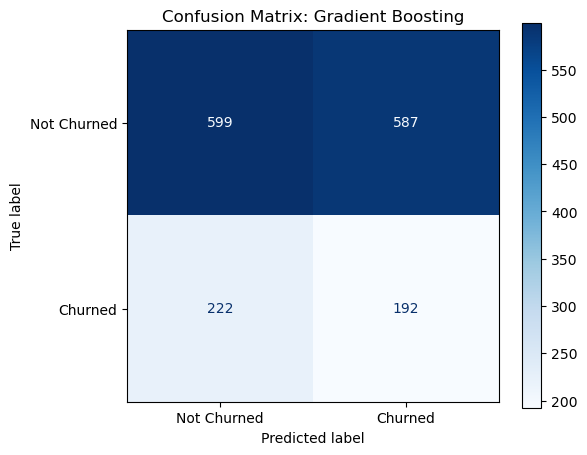

Saved: spotifyDataVisualizations/Gradient_Boosting_CM.png


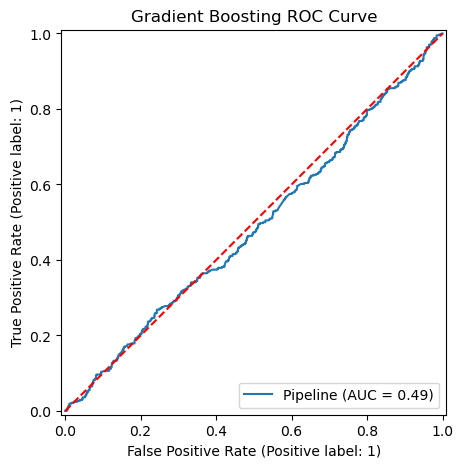

Saved: spotifyDataVisualizations/Gradient_Boosting_ROC.png


In [50]:
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Define the Pipeline
gb_pipe = Pipeline([
    ('gb', HistGradientBoostingClassifier(random_state=42))
])

# 2. Define the Parameter Grid
# max_iter: Equivalent to n_estimators (number of boosting rounds)
# max_depth: Limits the complexity of individual trees
# learning_rate: Controls how much each tree contributes
gb_param_grid = {
    'gb__max_iter': [100, 200],
    'gb__learning_rate': [0.01, 0.1],
    'gb__max_depth': [3, 5, 10],
    'gb__class_weight': ['balanced', None]
}

# 3. Initialize GridSearchCV
gb_grid = GridSearchCV(
    gb_pipe, 
    gb_param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 4. Fit the model
gb_grid.fit(X_train, y_train)

# 5. Report Results
print(f"Best Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best Cross-Val F1 Score: {gb_grid.best_score_:.4f}")

# 6. Visualize Results
plot_custom_cm(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")
plot_roc(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")

### Comparison of all the models

,Model,F1-Score,AUC,Accuracy,Precision,Recall
2,Decision Tree,0.358500,0.530000,0.480000,0.275000,0.514000
0,Balanced LASSO (Baseline),0.358000,0.580000,0.526000,0.274000,0.514000
5,Gradient Boosting,0.340400,0.490000,0.520000,0.258000,0.500000
6,SVM (RBF),0.334500,0.540000,0.530000,0.279000,0.517000
3,Random Forest,0.249600,0.510000,0.638000,0.272000,0.230000
1,KNN,0.201100,0.560000,0.779000,0.343000,0.234000
4,AdaBoost,0.003600,0.480000,0.730000,0.010000,0.002000


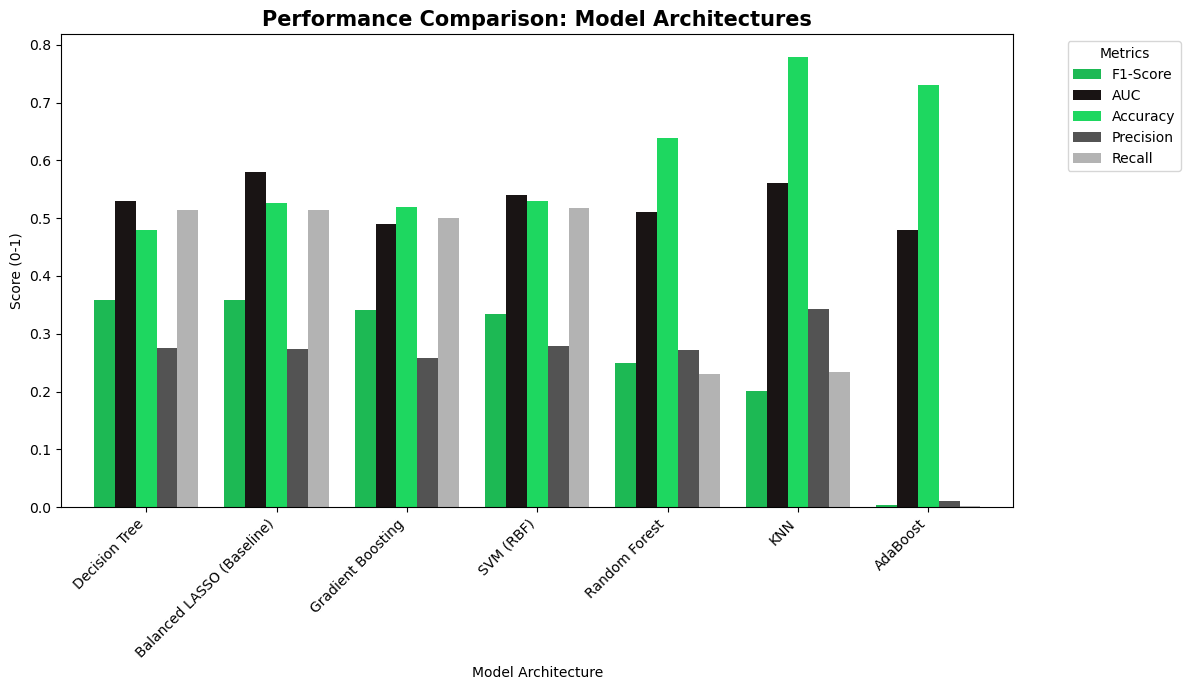

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Consolidated Data (Ensuring 'Model' is a column first)
results_data = {
    'Model': ['Balanced LASSO (Baseline)', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'SVM (RBF)'],
    'F1-Score': [0.3580, 0.2011, 0.3585, 0.2496, 0.0036, 0.3404, 0.3345],
    'AUC': [0.58, 0.56, 0.53, 0.51, 0.48, 0.49, 0.54],
    'Accuracy': [0.526, 0.779, 0.480, 0.638, 0.730, 0.520, 0.530],
    'Precision': [0.274, 0.343, 0.275, 0.272, 0.010, 0.258, 0.279],
    'Recall': [0.514, 0.234, 0.514, 0.230, 0.002, 0.500, 0.517]
}

comparison_df = pd.DataFrame(results_data).sort_values(by='F1-Score', ascending=False)

# 2. Formatted Display
# This adds the colors back to the notebook view
display(comparison_df.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='pink'))

# 3. Bar Chart with proper Model Names on X-axis
# We set the index locally for the plot so the names appear
plot_df = comparison_df.set_index('Model')
ax = plot_df.plot(kind='bar', figsize=(12, 7), width=0.8, 
                  color=['#1DB954', '#191414', '#1ed760', '#535353', '#b3b3b3'])

plt.title('Performance Comparison: Model Architectures', fontsize=15, fontweight='bold')
plt.ylabel('Score (0-1)')
plt.xlabel('Model Architecture')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 4. Save to your visualizations folder
plt.savefig('spotifyDataVisualizations/model_comparison_labeled.png', dpi=300)
plt.show()

### Summary 

Despite exploring a wide range of architectures—from distance-based (KNN) and linear-penalty (Balanced LASSO) to complex ensemble methods (Random Forest, Gradient Boosting, AdaBoost)—no model significantly outperformed the 0.3580 F1-Score baseline.

The primary finding of this exercise is that increased model complexity did not yield a performance gain. All top-performing models hovered at an AUC of ~0.50–0.58, indicating that the models are struggling to find a distinct mathematical boundary between active and churned users.

The fact that the Balanced LASSO (which prunes features) performed as well as or better than the more "powerful" ensemble models supports the hypothesis that the current dataset is hindered by Dimensionality Noise.

The steady performance of the Baseline Model suggests that any available signal in the current data is likely linear. Moving to complex, non-linear kernels (like SVM RBF) provided no benefit, hinting that the issue likely lies in the data representation, not the model choice.

We will revisit the feature engineering to see if working with original features improves model performance.